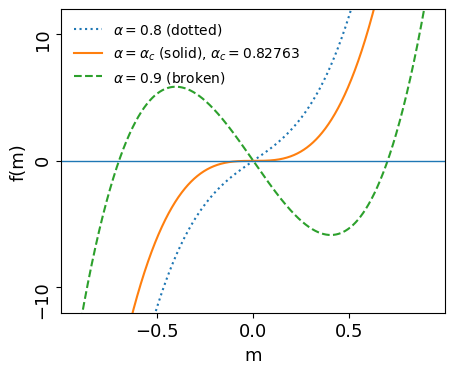

alpha_c(h=0) = 0.8276253029821987


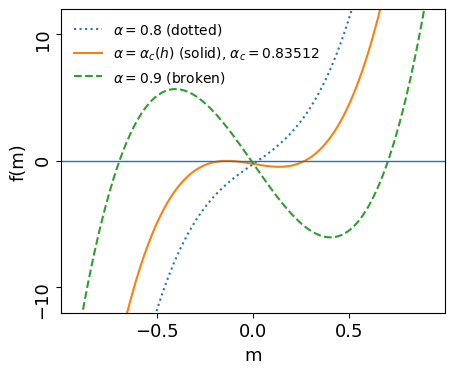

alpha_c(h=0.01) = 0.8351182404795314


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# Figure 1 (separate outputs) with:
#  - x ticks: [-0.5, 0.0, 0.5]
#  - y ticks: [-20, -10, 0, 10, 20]
#  - fontsize: 15
# -----------------------------

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 10,
    "axes.labelsize": 13,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 10,
})

tau = 1e2
J = 0.1
alpha1 = 0.8
alpha3 = 0.9

def a_of(alpha, tau):
    return 2.0 * ((tau / alpha**2) * (1.0 - alpha) - 1.0)

def B_of(alpha, J, tau):
    # (N-1)b = -4*(tau/alpha)*J
    return -4.0 * (tau / alpha) * J

def f_of(m, alpha, J, h, tau):
    a = a_of(alpha, tau)
    B = B_of(alpha, J, tau)
    return (a + B) * m - B * m**3 - 2.0 * (tau / alpha) * h * (1.0 - m**2)

def alpha_c_h0(J, tau):
    return (math.sqrt(tau**2 * (2.0 * J + 1.0)**2 + 4.0 * tau) - tau * (2.0 * J + 1.0)) / 2.0

def alpha_c_h_numeric(J, h, tau, lo=0.5, hi=0.999, tol=1e-12):
    def g(alpha):
        a = a_of(alpha, tau)
        B = B_of(alpha, J, tau)
        # f'(m)=0: (-3B)m^2 + 4*(tau/alpha)*h*m + (a+B)=0
        A = -3.0 * B
        Bq = 4.0 * (tau / alpha) * h
        C = (a + B)
        disc = Bq**2 - 4.0 * A * C
        if disc < 0:
            return None
        r1 = (-Bq + math.sqrt(disc)) / (2.0 * A)
        r2 = (-Bq - math.sqrt(disc)) / (2.0 * A)

        vals = []
        for m0 in (r1, r2):
            if abs(m0) <= alpha:  # constraint in the paper
                vals.append(f_of(m0, alpha, J, h, tau))
        if not vals:
            return None
        return max(vals)

    g_lo = g(lo)
    g_hi = g(hi)
    if g_lo is None: g_lo = -1.0
    if g_hi is None: g_hi = -1.0

    for _ in range(2000):
        if g_lo < 0 and g_hi > 0:
            break
        if g_hi <= 0:
            hi = (hi + 1.0) / 2.0
            g_hi = g(hi)
            if g_hi is None: g_hi = -1.0
        if g_lo >= 0:
            lo = (lo + hi) / 2.0
            g_lo = g(lo)
            if g_lo is None: g_lo = -1.0
    else:
        raise RuntimeError("Failed to bracket alpha_c(h). Try changing lo/hi.")

    for _ in range(400):
        mid = (lo + hi) / 2.0
        g_mid = g(mid)
        if g_mid is None: g_mid = -1.0
        if g_mid > 0:
            hi = mid
        else:
            lo = mid
        if abs(hi - lo) < tol:
            break
    return (lo + hi) / 2.0

# axis settings
xlim = (-1.0, 1.0)
ylim = (-12, 12)
xticks = np.arange(-0.5, 0.5 + 1e-9, 0.5)  # -0.5, 0, 0.5
yticks = np.arange(-10, 10 + 1e-9, 10)     # -20, -10, 0, 10, 20

# grid
m = np.linspace(xlim[0], xlim[1], 2000)

# -------- Left figure (h=0.0) --------
h = 0.0
alpha2 = alpha_c_h0(J, tau)

plt.figure(figsize=(5, 4))
plt.plot(m, f_of(m, alpha1, J, h, tau), ":",  label=r"$\alpha=0.8$ (dotted)")
plt.plot(m, f_of(m, alpha2, J, h, tau), "-",  label=rf"$\alpha=\alpha_c$ (solid), $\alpha_c={alpha2:.5f}$")
plt.plot(m, f_of(m, alpha3, J, h, tau), "--", label=r"$\alpha=0.9$ (broken)")
plt.axhline(0, linewidth=1)

plt.xlim(*xlim)
plt.ylim(*ylim)
plt.xticks(xticks)
plt.yticks(yticks)

plt.xlabel("m")
plt.ylabel("f(m)")
plt.legend(frameon=False)
plt.tight_layout()
plt.tick_params(axis='y', labelrotation=90) 
plt.show()

print("alpha_c(h=0) =", alpha2)

# -------- Right figure (h=0.01) --------
h = 0.001
alpha2 = alpha_c_h_numeric(J, h, tau)

plt.figure(figsize=(5, 4))
plt.plot(m, f_of(m, alpha1, J, h, tau), ":",  label=r"$\alpha=0.8$ (dotted)")
plt.plot(m, f_of(m, alpha2, J, h, tau), "-",  label=rf"$\alpha=\alpha_c(h)$ (solid), $\alpha_c={alpha2:.5f}$")
plt.plot(m, f_of(m, alpha3, J, h, tau), "--", label=r"$\alpha=0.9$ (broken)")
plt.axhline(0, linewidth=1)

plt.xlim(*xlim)
plt.ylim(*ylim)
plt.xticks(xticks)
plt.yticks(yticks)

plt.xlabel("m")
plt.ylabel("f(m)")
plt.legend(frameon=False)
plt.tight_layout()
plt.tick_params(axis='y', labelrotation=90) 
plt.show()

print("alpha_c(h=0.01) =", alpha2)


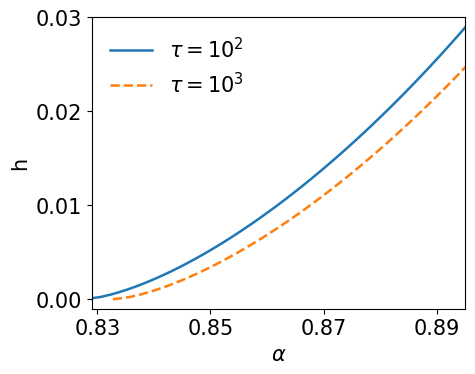

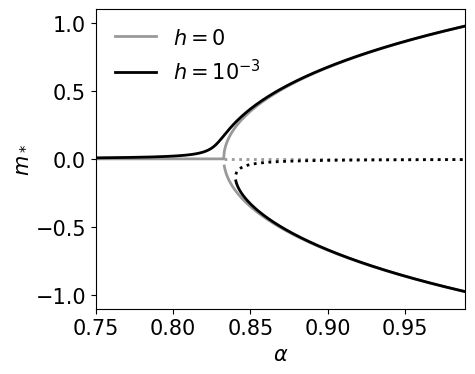

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import math

# -----------------------------
# Figure 2 (separate outputs)
#   Left : h vs alpha_c(h) for J=0.1, tau=1e2 (solid) and tau=1e3 (dashed)
#   Right: m* vs alpha for J=0.1, tau=1e3 with h=0.0 (gray) and h=1e-3 (black)
#          solid = maxima (m*), dotted = minima (m_t)
# -----------------------------

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
})

J = 0.1

def a_of(alpha, tau):
    return 2.0 * ((tau / alpha**2) * (1.0 - alpha) - 1.0)

def B_of(alpha, J, tau):
    # (N-1)b = -4*(tau/alpha)*J
    return -4.0 * (tau / alpha) * J

def f_of(m, alpha, J, h, tau):
    a = a_of(alpha, tau)
    B = B_of(alpha, J, tau)
    return (a + B) * m - B * m**3 - 2.0 * (tau / alpha) * h * (1.0 - m**2)

def alpha_c_h0(J, tau):
    return (math.sqrt(tau**2 * (2.0 * J + 1.0)**2 + 4.0 * tau) - tau * (2.0 * J + 1.0)) / 2.0

def alpha_c_h_numeric(J, h, tau, lo=0.5, hi=0.999, tol=1e-12):
    """
    h>0 のときの alpha_c(h) を数値で求める（接線条件: 局所最大値が 0 に一致）
    """
    if h == 0.0:
        return alpha_c_h0(J, tau)

    def g(alpha):
        a = a_of(alpha, tau)
        B = B_of(alpha, J, tau)

        # f'(m)=0 は二次方程式:
        # (-3B)m^2 + 4*(tau/alpha)*h*m + (a+B)=0
        A = -3.0 * B
        Bq = 4.0 * (tau / alpha) * h
        C = (a + B)

        disc = Bq**2 - 4.0 * A * C
        if disc < 0:
            return None

        r1 = (-Bq + math.sqrt(disc)) / (2.0 * A)
        r2 = (-Bq - math.sqrt(disc)) / (2.0 * A)

        vals = []
        for m0 in (r1, r2):
            if abs(m0) <= alpha:  # 制約 |m|<=alpha
                vals.append(f_of(m0, alpha, J, h, tau))

        if not vals:
            return None
        return max(vals)  # 局所最大の値（を含む方）

    g_lo = g(lo)
    g_hi = g(hi)
    if g_lo is None: g_lo = -1.0
    if g_hi is None: g_hi = -1.0

    # bracket
    for _ in range(2000):
        if g_lo < 0 and g_hi > 0:
            break
        if g_hi <= 0:
            hi = (hi + 1.0) / 2.0
            g_hi = g(hi)
            if g_hi is None: g_hi = -1.0
        if g_lo >= 0:
            lo = (lo + hi) / 2.0
            g_lo = g(lo)
            if g_lo is None: g_lo = -1.0
    else:
        raise RuntimeError("Failed to bracket alpha_c(h). Try changing lo/hi.")

    # bisection
    for _ in range(300):
        mid = 0.5 * (lo + hi)
        g_mid = g(mid)
        if g_mid is None:
            g_mid = -1.0
        if g_mid > 0:
            hi = mid
        else:
            lo = mid
        if abs(hi - lo) < tol:
            break

    return 0.5 * (lo + hi)

def cubic_coeffs(alpha, J, h, tau):
    """
    Eq.(13): (a+B)m - B m^3 - 2*(tau/alpha)*h*(1 - m^2) = 0
    -> c3*m^3 + c2*m^2 + c1*m + c0 = 0
    """
    a = a_of(alpha, tau)
    B = B_of(alpha, J, tau)
    c3 = -B
    c2 = 2.0 * (tau / alpha) * h
    c1 = (a + B)
    c0 = -2.0 * (tau / alpha) * h
    return c3, c2, c1, c0

def real_roots_in_domain(alpha, J, h, tau, imag_tol=1e-9):
    c3, c2, c1, c0 = cubic_coeffs(alpha, J, h, tau)
    roots = np.roots([c3, c2, c1, c0])

    real_roots = []
    for r in roots:
        if abs(r.imag) < imag_tol:
            rr = float(r.real)
            if (-alpha - 1e-9) <= rr <= (alpha + 1e-9):
                real_roots.append(rr)

    real_roots = np.array(sorted(real_roots))

    # merge near-duplicates
    if len(real_roots) >= 2:
        merged = [real_roots[0]]
        for x in real_roots[1:]:
            if abs(x - merged[-1]) > 1e-7:
                merged.append(x)
        real_roots = np.array(merged)

    return real_roots

def branches_m_star(alpha_grid, J, h, tau):
    """
    3根のとき: (小, 中, 大) = (max, min, max) として描く
    """
    m_max_top = np.full_like(alpha_grid, np.nan, dtype=float)
    m_max_bottom = np.full_like(alpha_grid, np.nan, dtype=float)
    m_min = np.full_like(alpha_grid, np.nan, dtype=float)

    for i, alpha in enumerate(alpha_grid):
        roots = real_roots_in_domain(alpha, J, h, tau)
        if len(roots) == 1:
            m_max_top[i] = roots[0]
        elif len(roots) == 2:
            m_min[i] = roots[0]
            m_max_top[i] = roots[1]
        elif len(roots) == 3:
            m_max_bottom[i] = roots[0]
            m_min[i] = roots[1]
            m_max_top[i] = roots[2]

    return m_max_top, m_max_bottom, m_min


# =========================
# Figure 2 (LEFT) as a single figure
# =========================
h_grid = np.linspace(0.0, 0.03, 121)

plt.figure(figsize=(5, 4))
for tau, ls, lab in [
    (1e2, "-",  r"$\tau=10^2$"),
    (1e3, "--", r"$\tau=10^3$")
]:
    alpha_cs = np.array([alpha_c_h_numeric(J, float(h), tau) for h in h_grid], dtype=float)
    plt.plot(alpha_cs, h_grid, ls, linewidth=1.8, label=lab)

plt.xlabel(r"$\alpha$")
plt.ylabel("h")
plt.xlim(0.829, 0.895)
plt.ylim(-0.001, 0.03)
plt.xticks([0.83, 0.85, 0.87, 0.89])
plt.yticks([0.00, 0.01, 0.02, 0.03])
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


# =========================
# Figure 2 (RIGHT) as a single figure
# =========================
tau_right = 1e3
alpha_min = 0.75
alpha_max = 1.0 - 1.0/tau_right
alpha_grid = np.linspace(alpha_min, alpha_max, 600)

plt.figure(figsize=(5, 4))

# h = 0.0 (gray)
m_top, m_bot, m_min_arr = branches_m_star(alpha_grid, J, h=0.0, tau=tau_right)
plt.plot(alpha_grid, m_top, color="0.6", linewidth=2.0, label=r"$h=0$")
plt.plot(alpha_grid, m_bot, color="0.6", linewidth=2.0)
plt.plot(alpha_grid, m_min_arr, color="0.6", linestyle=":", linewidth=2.0)

# h = 1e-3 (black)
m_top, m_bot, m_min_arr = branches_m_star(alpha_grid, J, h=1e-3, tau=tau_right)
plt.plot(alpha_grid, m_top, color="k", linewidth=2.0, label=r"$h=10^{-3}$")
plt.plot(alpha_grid, m_bot, color="k", linewidth=2.0)
plt.plot(alpha_grid, m_min_arr, color="k", linestyle=":", linewidth=2.0)

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$m_*$")
plt.xlim(alpha_min, alpha_max-0.01)
plt.ylim(-1.1, 1.1)
plt.xticks([0.75, 0.80, 0.85, 0.90, 0.95])
plt.yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

def a_alpha(alpha: float, tau: float) -> float:
    """
    paper's a(alpha): 2 * ((tau/alpha^2)*(1-alpha) - 1)
    """
    return 2.0 * ((tau / (alpha**2)) * (1.0 - alpha) - 1.0)

def b_off(alpha: float, tau: float, J: float, N: int) -> float:
    """
    paper's b = -4*(tau/alpha)*J/(N-1)
    """
    return -4.0 * (tau / alpha) * (J / (N - 1))

def cubic_roots_eq13(alpha: float, tau: float, J: float, h: float, N: int):
    """
    Solve eq.(13) cubic for homogeneous fully-connected case.
    Returns all real roots within [-alpha, alpha].
    """
    a = a_alpha(alpha, tau)
    b = b_off(alpha, tau, J, N)

    # eq.(13):
    # (a+(N-1)b)m - (N-1)b m^3 - 2*(tau/alpha)*h*(1-m^2)=0
    # => c3*m^3 + c2*m^2 + c1*m + c0 = 0
    c3 = -(N - 1) * b
    c2 =  2.0 * (tau / alpha) * h
    c1 =  (a + (N - 1) * b)
    c0 = -2.0 * (tau / alpha) * h

    coeffs = np.array([c3, c2, c1, c0], dtype=float)
    r = np.roots(coeffs)

    # filter real roots within [-alpha, alpha]
    roots = []
    for z in r:
        if abs(z.imag) < 1e-10:
            x = float(z.real)
            if abs(x) <= alpha + 1e-12:
                roots.append(x)
    roots = np.array(sorted(roots))
    return roots

def log_pst_homogeneous(m: float, alpha: float, tau: float, J: float, h: float, N: int) -> float:
    """
    log p_st(m) up to an additive constant, specialized to homogeneous case.
    Enough for comparing modes.
    """
    if abs(m) >= 1.0:
        return -np.inf

    a = a_alpha(alpha, tau)
    # per-spin term: 0.5*a*log(1-m^2) + 2*(tau/alpha)*(h*m + J*m^2)
    return N * (0.5 * a * np.log(1.0 - m**2) + 2.0 * (tau / alpha) * (h * m + J * m**2))

def theoretical_modes(alpha: float, tau: float, J: float, h: float, N: int,
                      tie_tol: float = 1e-6):
    """
    Returns the mode(s) of p_st(m) for given (alpha, tau, J, h, N).

    - Usually returns 1 mode (single peak).
    - Near/above alpha_c, may return 2 modes (bimodal). At alpha=alpha_c,
      the top two maxima have ~equal log_p, so this returns both.

    tie_tol: relative tolerance for declaring "same height" maxima.
    """
    roots = cubic_roots_eq13(alpha, tau, J, h, N)
    if roots.size == 0:
        raise RuntimeError("No valid real roots found in [-alpha, alpha]. Check parameters.")

    scores = np.array([log_pst_homogeneous(m, alpha, tau, J, h, N) for m in roots])
    best = np.max(scores)

    # modes = roots whose score is essentially tied for best
    # Use absolute tolerance on log scale: |score-best| <= tie_tol*max(1,|best|)
    atol = tie_tol * max(1.0, abs(best))
    modes = roots[np.where(np.abs(scores - best) <= atol)[0]]

    # In practice, numerical ties can include very close roots; de-duplicate
    modes = np.unique(np.round(modes, 10))
    return modes

def estimate_alpha_c(tau: float, J: float, h: float, N: int,
                     alpha_min: float = 0.1, alpha_max: float = None,
                     grid: int = 400, tie_tol: float = 1e-5):
    """
    Roughly estimate alpha_c(h) by scanning alpha and finding where the
    distribution becomes effectively bimodal (two modes tied at top).

    Returns: (alpha_c_est, modes_at_alpha_c)
    """
    if alpha_max is None:
        # paper constraint: alpha <= 1 - 1/tau to keep a(alpha)>0
        alpha_max = 1.0 - 1.0 / tau

    alphas = np.linspace(alpha_min, alpha_max, grid)
    candidate = None

    for a in alphas:
        modes = theoretical_modes(a, tau, J, h, N, tie_tol=tie_tol)
        if len(modes) >= 2:
            candidate = (a, modes)
            break

    if candidate is None:
        return None, None

    return candidate




In [39]:
import numpy as np
import matplotlib.pyplot as plt

def plot_hist_with_modes(M_data: np.ndarray,
                         alpha: float, tau: float, J: float, h: float, N: int,
                         bins: int = 120, density: bool = True,
                         show_two_modes: bool = True,
                         title: str = None):
    """
    Plot histogram of M_data and overlay vertical line(s) at theoretical mode(s).
    M_data: 1D array of sampled m = 2*alpha*(Z-1/2)
    """
    M_data = np.asarray(M_data).ravel()

    # histogram range matches theoretical support [-alpha, alpha]
    hist_range = (-alpha, alpha)

    plt.figure(figsize=(7, 4.5))
    plt.hist(M_data, bins=bins, range=hist_range, density=density,
             alpha=0.6, label="Simulation (hist)")

    modes = theoretical_modes(alpha, tau, J, h, N, tie_tol=1e-6)

    if not show_two_modes and len(modes) > 0:
        modes = np.array([modes[np.argmax(np.abs(modes))]])  # pick one deterministically

    for m in modes:
        plt.axvline(m, linestyle="--", linewidth=2, label=f"Theory mode: {m:.4f}")

    plt.xlim(hist_range)
    plt.xlabel("m")
    plt.ylabel("p(m)" if density else "count")
    if title is None:
        title = f"Histogram + theoretical mode(s)  (alpha={alpha}, tau={tau})"
    plt.title(title)

    # avoid duplicate legend entries if two modes
    handles, labels = plt.gca().get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    plt.legend(uniq.values(), uniq.keys(), frameon=False)

    plt.tight_layout()
    plt.show()


# -------------------------
# Usage example
# -------------------------
# 例: Julia で作った M を csv や npy に落として読み込む想定
# M_data = np.load("M_samples.npy")  # or np.loadtxt("M_samples.csv")

# parameters (Fig.3 style)
# N = 100
# J = 0.1
# h = 1e-3
# tau = 1e2
# alpha = 0.8   # or alpha_c(h) or 0.9
# plot_hist_with_modes(M_data, alpha, tau, J, h, N, bins=120, density=True)


In [41]:
import numpy as np

def a_alpha(alpha: float, tau: float) -> float:
    # a(alpha) = 2*((tau/alpha^2)*(1-alpha) - 1)
    return 2.0 * ((tau / (alpha**2)) * (1.0 - alpha) - 1.0)

def b_off(alpha: float, tau: float, J: float, N: int) -> float:
    # b = -4*(tau/alpha)*J/(N-1)
    return -4.0 * (tau / alpha) * (J / (N - 1))

def cubic_roots_eq13(alpha: float, tau: float, J: float, h: float, N: int) -> np.ndarray:
    """
    Solve the homogeneous cubic (paper eq.(13)).
    Return real roots within [-alpha, alpha].
    """
    a = a_alpha(alpha, tau)
    b = b_off(alpha, tau, J, N)

    # (a+(N-1)b)m - (N-1)b m^3 - 2(tau/alpha)h(1-m^2)=0
    c3 = -(N - 1) * b
    c2 =  2.0 * (tau / alpha) * h
    c1 =  (a + (N - 1) * b)
    c0 = -2.0 * (tau / alpha) * h

    coeffs = np.array([c3, c2, c1, c0], dtype=float)
    r = np.roots(coeffs)

    roots = []
    for z in r:
        if abs(z.imag) < 1e-10:
            x = float(z.real)
            if abs(x) <= alpha + 1e-12:
                roots.append(x)
    return np.array(sorted(roots), dtype=float)

def log_pst_homogeneous(m: float, alpha: float, tau: float, J: float, h: float, N: int) -> float:
    """
    log p_st(m) up to constant (homogeneous specialization of eq.(11)).
    Used only for comparing which root is the mode.
    """
    if abs(m) >= 1.0:
        return -np.inf
    a = a_alpha(alpha, tau)
    # N * [ 0.5*a*log(1-m^2) + 2*(tau/alpha)*(h*m + J*m^2) ]
    return N * (0.5 * a * np.log(1.0 - m*m) + 2.0 * (tau / alpha) * (h * m + J * m*m))

def theoretical_modes(alpha: float, tau: float, J: float, h: float, N: int,
                      tie_tol: float = 1e-7) -> np.ndarray:
    """
    Return mode(s) of p_st(m). Usually 1 value.
    At/near alpha_c, two peaks can have almost equal height -> return both (two vertical lines).
    """
    roots = cubic_roots_eq13(alpha, tau, J, h, N)
    if roots.size == 0:
        raise RuntimeError("No real roots in [-alpha, alpha]. Check parameters.")

    scores = np.array([log_pst_homogeneous(m, alpha, tau, J, h, N) for m in roots])
    best = scores.max()

    # Treat as "tied" if within atol on log scale
    atol = tie_tol * max(1.0, abs(best))
    modes = roots[np.abs(scores - best) <= atol]

    # de-duplicate numerically
    modes = np.unique(np.round(modes, 10))
    return modes


In [42]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---- ここをあなたのトップディレクトリに合わせる ----
BASE = Path("/home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000")

# 実験条件（あなたが提示した alpha_c）
ALPHA_C = {
    (100, 0.0):   0.827625,
    (100, 0.001): 0.835118,
    (1000, 0.0):  0.832755,
    (1000, 0.001):0.840389,
}

# 固定（実験で共通）
N_DEFAULT = 100
J_DEFAULT = 0.1

def parse_tau_foldername(foldername: str) -> int:
    # "tau100" or "tau1K"
    m = re.search(r"tau(\d+)(K)?", foldername)
    if not m:
        raise ValueError(f"Cannot parse tau from: {foldername}")
    val = int(m.group(1))
    if m.group(2) == "K":
        val *= 1000
    return val

def parse_h_foldername(foldername: str) -> float:
    # "h0.0" or "h0.001"
    m = re.search(r"h([0-9]*\.?[0-9]+)", foldername)
    if not m:
        raise ValueError(f"Cannot parse h from: {foldername}")
    return float(m.group(1))

def parse_J_foldername(foldername: str) -> float:
    m = re.search(r"J([0-9]*\.?[0-9]+)", foldername)
    if not m:
        raise ValueError(f"Cannot parse J from: {foldername}")
    return float(m.group(1))

def parse_alpha_from_filename(fname: str, tau: int, h: float) -> float:
    """
    ファイル名に alpha0.8 / alpha0.9 が入っていればそれを採用。
    そうでなければ alpha_c 用として ALPHA_C[(tau,h)] を使う。
    """
    m = re.search(r"alpha([0-9]*\.?[0-9]+)", fname)
    if m:
        return float(m.group(1))
    # alpha が書いてなければ alpha_c とみなす（あなたの命名がそうなっている前提）
    return ALPHA_C[(tau, h)]

def load_csv_vector(csv_path: Path) -> np.ndarray:
    x = np.loadtxt(csv_path, delimiter=",")
    return np.asarray(x).ravel()

def plot_hist_with_modes(M_data: np.ndarray, *, alpha: float, tau: int, J: float, h: float, N: int,
                         bins: int = 120, density: bool = True,
                         outpath: Path = None):
    M_data = np.asarray(M_data).ravel()

    hist_range = (-alpha, alpha)

    plt.figure(figsize=(7, 4.5))
    plt.hist(M_data, bins=bins, range=hist_range, density=density,
             alpha=0.6, label="Sim (hist)")

    modes = theoretical_modes(alpha, float(tau), float(J), float(h), int(N), tie_tol=1e-7)
    for m in modes:
        plt.axvline(m, linestyle="--", linewidth=2, label=f"Theory mode {m:.4f}")

    plt.xlim(hist_range)
    plt.xlabel("m")
    plt.ylabel("p(m)" if density else "count")
    plt.title(f"tau={tau}, h={h}, J={J}, alpha={alpha}")
    # legend重複を避ける
    handles, labels = plt.gca().get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    plt.legend(uniq.values(), uniq.keys(), frameon=False)

    plt.tight_layout()
    if outpath is not None:
        outpath.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(outpath, dpi=200)
    plt.close()

def run_all():
    # BASE/ tau*_h*_J*_α_inc*/ の下のCSVを全部拾う
    folders = sorted([p for p in BASE.glob("tau*_h*_J*_α_inc*") if p.is_dir()])

    if not folders:
        raise RuntimeError(f"No folders found under {BASE}")

    for d in folders:
        tau = parse_tau_foldername(d.name)
        h = parse_h_foldername(d.name)
        J = parse_J_foldername(d.name)

        # プロット保存先
        outdir = d / "plots_pm"
        outdir.mkdir(exist_ok=True)

        csvs = sorted(d.glob("*.csv"))
        if not csvs:
            print(f"[skip] no csv in {d}")
            continue

        for csv_path in csvs:
            alpha = parse_alpha_from_filename(csv_path.name, tau, h)
            M_data = load_csv_vector(csv_path)

            outname = csv_path.stem + "_hist_mode.png"
            outpath = outdir / outname

            plot_hist_with_modes(
                M_data,
                alpha=alpha, tau=tau, J=J, h=h, N=N_DEFAULT,
                bins=120, density=True,
                outpath=outpath
            )
            print(f"[ok] {csv_path} -> {outpath}")

if __name__ == "__main__":
    run_all()


ValueError: could not convert string 't' to float64 at row 0, column 1.

In [43]:
import numpy as np

def a_alpha(alpha: float, tau: float) -> float:
    # paper: a(alpha) = 2*((tau/alpha^2)*(1-alpha) - 1)
    return 2.0 * ((tau / (alpha**2)) * (1.0 - alpha) - 1.0)

def b_off(alpha: float, tau: float, J: float, N: int) -> float:
    # paper: b = -4*(tau/alpha)*J/(N-1)
    return -4.0 * (tau / alpha) * (J / (N - 1))

def cubic_roots_eq13(alpha: float, tau: float, J: float, h: float, N: int) -> np.ndarray:
    """
    Solve eq.(13) cubic (homogeneous fully-connected case).
    Return real roots within [-alpha, alpha].
    """
    a = a_alpha(alpha, tau)
    b = b_off(alpha, tau, J, N)

    # (a+(N-1)b)m - (N-1)b m^3 - 2*(tau/alpha)*h*(1-m^2)=0
    c3 = -(N - 1) * b
    c2 =  2.0 * (tau / alpha) * h
    c1 =  (a + (N - 1) * b)
    c0 = -2.0 * (tau / alpha) * h

    r = np.roots([c3, c2, c1, c0])

    roots = []
    for z in r:
        if abs(z.imag) < 1e-10:
            x = float(z.real)
            if abs(x) <= alpha + 1e-12:
                roots.append(x)
    return np.array(sorted(roots), dtype=float)

def log_pst_homogeneous(m: float, alpha: float, tau: float, J: float, h: float, N: int) -> float:
    """
    log p_st(m) up to constant (homogeneous specialization of eq.(11)).
    Used only for comparing which root is the mode.
    """
    if abs(m) >= 1.0:
        return -np.inf
    a = a_alpha(alpha, tau)
    return N * (0.5 * a * np.log(1.0 - m*m) + 2.0 * (tau / alpha) * (h * m + J * m*m))

def theoretical_modes(alpha: float, tau: float, J: float, h: float, N: int,
                      tie_tol: float = 1e-7) -> np.ndarray:
    """
    Return mode(s) of p_st(m).
    - typically 1 mode
    - near alpha_c: two peaks can have almost the same height -> returns both (two vertical lines)
    """
    roots = cubic_roots_eq13(alpha, tau, J, h, N)
    if roots.size == 0:
        raise RuntimeError("No real roots found in [-alpha, alpha].")

    scores = np.array([log_pst_homogeneous(m, alpha, tau, J, h, N) for m in roots])
    best = scores.max()

    atol = tie_tol * max(1.0, abs(best))
    modes = roots[np.abs(scores - best) <= atol]
    return np.unique(np.round(modes, 10))


In [45]:
import numpy as np
from pathlib import Path

def load_M_from_tm_csv(csv_path: str | Path) -> np.ndarray:
    """
    CSV is like:
      t,M
      1,0.8
      2,0.9
      ...
    -> return only M column (float array)
    """
    arr = np.genfromtxt(csv_path, delimiter=",", skip_header=1)  # shape (n,2)
    if arr.ndim == 1:
        # if only one data row, genfromtxt returns 1D
        arr = arr.reshape(1, -1)
    if arr.shape[1] < 2:
        raise ValueError(f"Expected at least 2 columns (t,M) in {csv_path}, got shape {arr.shape}")
    M = arr[:, 1].astype(float)
    return M

import matplotlib.pyplot as plt

def plot_hist_with_modes_from_csv(csv_path, *, alpha, tau, J, h, N,
                                 bins=120, density=True, outpath=None):
    M_data = load_M_from_tm_csv(csv_path)

    # histogram support
    hist_range = (-alpha, alpha)

    plt.figure(figsize=(7, 4.5))
    plt.hist(M_data, bins=bins, range=hist_range, density=density,
             alpha=0.6, label="Sim (hist)")

    modes = theoretical_modes(alpha, float(tau), float(J), float(h), int(N), tie_tol=1e-7)
    for m in modes:
        plt.axvline(m, linestyle="--", linewidth=2, label=f"Theory mode {m:.4f}")

    plt.xlim(hist_range)
    plt.xlabel("m")
    plt.ylabel("p(m)" if density else "count")
    plt.title(f"{Path(csv_path).name}  |  tau={tau}, h={h}, alpha={alpha}")
    # legend重複回避
    handles, labels = plt.gca().get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    plt.legend(uniq.values(), uniq.keys(), frameon=False)

    plt.tight_layout()
    if outpath is not None:
        outpath = Path(outpath)
        outpath.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(outpath, dpi=200)
        plt.close()
    else:
        plt.show()


In [46]:
from pathlib import Path

BASE = Path("/home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000")

ALPHA_C = {
    (100, 0.0):   0.827625,
    (100, 0.001): 0.835118,
    (1000, 0.0):  0.832755,
    (1000, 0.001):0.840389,
}

taus = [100, 1000]
hs = [0.0, 0.001]
alphas = ["0.8", "ac", "0.9"]  # ファイル名の alpha 部分に合わせる（後述）

N = 100
J = 0.1

def tau_to_folder(tau):
    return "tau100" if tau == 100 else "tau1K"

def h_to_folder(h):
    return f"h{h}"

def find_csv_for_alpha(folder: Path, alpha_key: str, tau: int, h: float):
    """
    あなたのファイル名が
      ..._alpha0.8_...
      ..._alpha0.9_...
      ..._alpha0.827625_... (alpha_c そのもの)
    みたいになっている想定。
    もし alpha_c が 'alpha_ac' みたいな命名ならここを変える。
    """
    if alpha_key == "ac":
        a = ALPHA_C[(tau, h)]
        pattern = f"*alpha{a}*.csv"
    else:
        pattern = f"*alpha{alpha_key}*.csv"

    hits = sorted(folder.glob(pattern))
    if not hits:
        raise FileNotFoundError(f"No CSV found: {folder} / {pattern}")
    return hits[0]  # 1つ目を採用

for tau in taus:
    for h in hs:
        # 例: tau1K_h0.0_J0.1_α_inc1.0e-6
        # あなたのフォルダ名に完全一致するように必要なら微調整してください
        folder = sorted(BASE.glob(f"{tau_to_folder(tau)}_{h_to_folder(h)}_J{J}_α_inc*"))[0]

        for akey in alphas:
            alpha_val = ALPHA_C[(tau, h)] if akey == "ac" else float(akey)
            csv_path = find_csv_for_alpha(folder, akey, tau, h)

            outpath = folder / "plots_pm" / f"{csv_path.stem}_overlay.png"
            plot_hist_with_modes_from_csv(
                csv_path,
                alpha=alpha_val, tau=tau, J=J, h=h, N=N,
                bins=120, density=True, outpath=outpath
            )
            print("saved:", outpath)


saved: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.0_J0.1_α_inc1.0e-6/plots_pm/N100_alpha0.827625_sample5K_overlay.png
saved: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.0_J0.1_α_inc1.0e-6/plots_pm/N100_alpha0.827625_sample5K_overlay.png
saved: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.0_J0.1_α_inc1.0e-6/plots_pm/N100_alpha0.9_sample5K_overlay.png
saved: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.001_J0.1_α_inc1.0e-6/plots_pm/N100_alpha0.835118_sample5K_overlay.png
saved: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.001_J0.1_α_inc1.0e-6/plots_pm/N100_alpha0.835118_sample5K_overlay.png
saved: /home/mori-lab/shimizu/aco-on-spinglass/src/sampling/return_M/data/seed1000/tau100_h0.001_J0.1_α_inc1.0e-6/plots_pm/N100_alpha0.99_sample10_overlay.png
saved: /home/mori-lab/shimizu/aco-on-

estimated alpha_c ≈ 0.8404156039009752


/tmp/ipykernel_500059/2586993912.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Z = np.trapz(p, m)


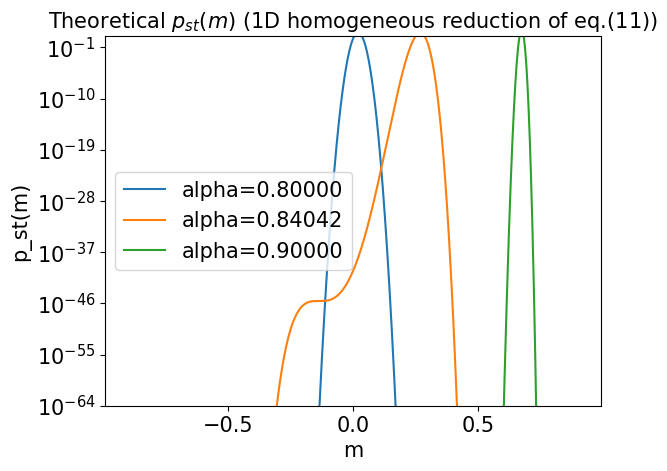

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- model / paper functions ----------
def a_alpha(alpha, tau):
    # paper: a(α)=2*((τ/α^2)(1-α) - 1)
    return 2.0 * ((tau / alpha**2) * (1.0 - alpha) - 1.0)

def log_p_st_m(m, alpha, tau, J, h, N):
    """
    1D "homogeneous" reduction of eq.(11):
      log p(m) = N[ 0.5 a(α) log(1-m^2) + 2(τ/α)(h m + J m^2) ]
    support: m in [-α, α]
    """
    a = a_alpha(alpha, tau)
    # avoid log(0) at boundaries
    return N * (0.5 * a * np.log(1.0 - m**2) + 2.0 * (tau / alpha) * (h * m + J * m**2))

def normalized_pdf(alpha, tau, J, h, N, ngrid=4001):
    """
    Compute normalized p(m) on m∈[-α,α] using stable exp(logp - max(logp)).
    """
    eps = 1e-6
    m = np.linspace(-alpha + eps, alpha - eps, ngrid)
    logp = log_p_st_m(m, alpha, tau, J, h, N)
    logp -= np.max(logp)
    p = np.exp(logp)
    # normalize
    Z = np.trapz(p, m)
    p /= Z
    return m, p

# ---------- alpha_c estimation via cubic equation (paper eq.(cubic)) ----------
def cubic_real_roots(alpha, tau, J, h, N, tol=1e-10):
    """
    Solve paper cubic for homogeneous mode m_*:
      (a+(N-1)b)m - (N-1)b m^3 - 2(τ/α) h (1 - m^2)=0
    where b = -4(τ/α) * J/(N-1)
    Return real roots within [-α, α].
    """
    a = a_alpha(alpha, tau)
    b = -4.0 * (tau / alpha) * (J / (N - 1.0))

    # Expand to polynomial: c3 m^3 + c2 m^2 + c1 m + c0 = 0
    # -(N-1)b m^3 + 2(τ/α)h m^2 + (a+(N-1)b)m - 2(τ/α)h = 0
    c3 = -(N - 1.0) * b
    c2 =  2.0 * (tau / alpha) * h
    c1 =  (a + (N - 1.0) * b)
    c0 = -2.0 * (tau / alpha) * h

    roots = np.roots([c3, c2, c1, c0])
    real_roots = []
    for r in roots:
        if abs(r.imag) < tol:
            rr = float(r.real)
            if -alpha - 1e-8 <= rr <= alpha + 1e-8:
                real_roots.append(rr)
    real_roots = sorted(real_roots)
    return real_roots

def estimate_alpha_c(tau, J, h, N, a_min=0.6, a_max=0.999, nscan=2000):
    """
    Roughly estimate α_c(h) as the smallest α where the cubic has 3 real roots
    (within [-α,α]). For h>0, below α_c typically 1 real root; above α_c, 3 roots.
    """
    alphas = np.linspace(a_min, a_max, nscan)
    for alpha in alphas:
        rr = cubic_real_roots(alpha, tau, J, h, N)
        # count unique roots (avoid numerical duplicates)
        uniq = []
        for x in rr:
            if not uniq or abs(x - uniq[-1]) > 1e-5:
                uniq.append(x)
        if len(uniq) >= 3:
            return alpha
    return None

# ---------- demo plot ----------
if __name__ == "__main__":
    # parameters similar to the paper figures
    N = 100
    J = 0.1
    h = 1e-3
    tau = 10**3

    alpha_c = estimate_alpha_c(tau, J, h, N, a_min=0.7, a_max=0.999, nscan=4000)
    print("estimated alpha_c ≈", alpha_c)

    # choose alphas around alpha_c
    alpha_list = [0.8, alpha_c, 0.9] if alpha_c is not None else [0.8, 0.9, 0.95]

    plt.figure()
    for alpha in alpha_list:
        m, p = normalized_pdf(alpha, tau, J, h, N)
        plt.plot(m, p, label=f"alpha={alpha:.5f}")

    plt.title(r"Theoretical $p_{st}(m)$ (1D homogeneous reduction of eq.(11))")
    plt.xlabel("m")
    plt.ylabel("p_st(m)")
    plt.legend()
    plt.yscale('log')
    plt.ylim(10**(-64),10)
    plt.show()


In [56]:
import numpy as np

def a_alpha(alpha, tau):
    return 2.0 * ((tau / alpha**2) * (1.0 - alpha) - 1.0)

def log_p_st_m(m, alpha, tau, J, h, N):
    a = a_alpha(alpha, tau)
    return N * (0.5 * a * np.log(1.0 - m**2) + 2.0 * (tau / alpha) * (h * m + J * m**2))

def cubic_roots_homogeneous(alpha, tau, J, h, N, tol=1e-10):
    """
    論文の homogeneous cubic:
      (a+(N-1)b)m - (N-1)b m^3 - 2(τ/α) h (1-m^2)=0
    b = -4(τ/α) * J/(N-1)
    """
    a = a_alpha(alpha, tau)
    b = -4.0 * (tau / alpha) * (J / (N - 1.0))

    # polynomial coefficients:
    # -(N-1)b m^3 + 2(τ/α)h m^2 + (a+(N-1)b)m - 2(τ/α)h = 0
    c3 = -(N - 1.0) * b
    c2 =  2.0 * (tau / alpha) * h
    c1 =  (a + (N - 1.0) * b)
    c0 = -2.0 * (tau / alpha) * h

    roots = np.roots([c3, c2, c1, c0])
    real_roots = []
    for r in roots:
        if abs(r.imag) < tol:
            rr = float(r.real)
            if -alpha < rr < alpha:  # サポート内
                real_roots.append(rr)
    real_roots = sorted(real_roots)
    return real_roots

def peaks_from_cubic(alpha, tau, J, h, N, top_k=2):
    roots = cubic_roots_homogeneous(alpha, tau, J, h, N)
    if len(roots) == 0:
        return []

    # 各根で log p(m) を評価して大きい順
    scored = []
    for r in roots:
        # log(1-r^2)が壊れないように安全側
        if 1.0 - r*r <= 0:
            continue
        lp = log_p_st_m(r, alpha, tau, J, h, N)
        scored.append((r, lp))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]

# ---- 使い方例 ----
if __name__ == "__main__":
    N = 100
    J = 0.1
    h = 1e-3
    tau = 10**2
    alpha = 0.9

    peaks = peaks_from_cubic(alpha, tau, J, h, N, top_k=2)
    print("peaks from cubic (m_peak, logp):")
    for mp, lp in peaks:
        print(f"  m_peak ≈ {mp:.6f}, logp ≈ {lp:.6f}")


peaks from cubic (m_peak, logp):
  m_peak ≈ 0.702178, logp ≈ 340.509912
  m_peak ≈ -0.696961, logp ≈ 309.416935


Saved:
  fig_choice_probability_curve.png
  fig_pheromone_rate_timeseries_alpha_0.1.png
  fig_pheromone_rate_timeseries_alpha_0.5.png
  fig_pheromone_rate_timeseries_alpha_0.9.png


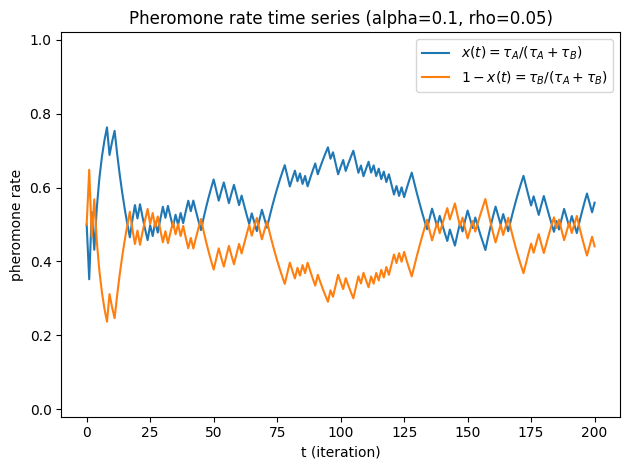

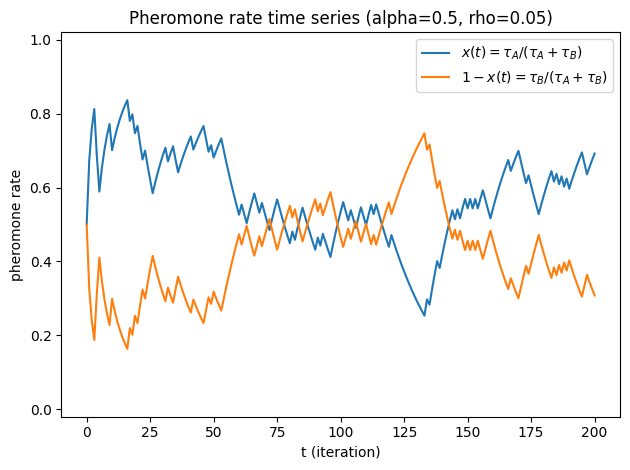

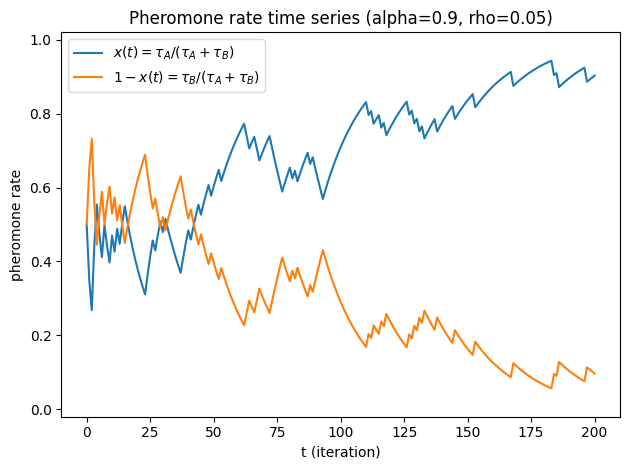

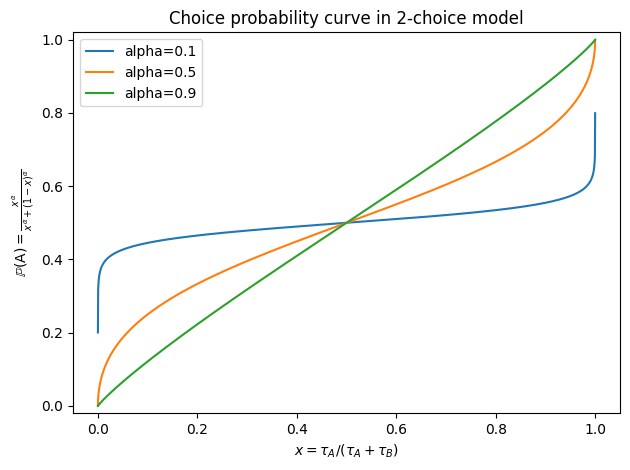

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 2-choice ACO toy simulation
# -----------------------------
def simulate_2choice_aco(
    alpha: float,
    T: int = 200,
    rho: float = 0.05,
    tau0: float = 1.0,
    Q: float = 1.0,
    reward_A: float = 1.0,
    reward_B: float = 0.8,
    seed: int = 0,
):
    """
    2択ACOの簡単モデル：
      - 意思決定: P(A)=tauA^alpha/(tauA^alpha+tauB^alpha)
      - 蒸発: tau <- (1-rho)*tau
      - 付与: 選ばれた側に Q*reward を加える（reward_A > reward_B を想定）
    出力:
      - x[t] = tauA/(tauA+tauB) の時系列 (t=0..T)
      - pA[t] = P_t(A) の時系列 (t=0..T-1)
      - tauA, tauB の時系列
    """
    rng = np.random.default_rng(seed)

    tauA = tau0
    tauB = tau0

    x = np.zeros(T + 1)
    pA = np.zeros(T)
    tauA_hist = np.zeros(T + 1)
    tauB_hist = np.zeros(T + 1)

    def pheromone_rate(a, b):
        s = a + b
        return a / s

    x[0] = pheromone_rate(tauA, tauB)
    tauA_hist[0] = tauA
    tauB_hist[0] = tauB

    for t in range(T):
        # decision probability
        denom = (tauA ** alpha) + (tauB ** alpha)
        p = (tauA ** alpha) / denom
        pA[t] = p

        # sample choice
        choose_A = (rng.random() < p)

        # evaporation
        tauA *= (1.0 - rho)
        tauB *= (1.0 - rho)

        # deposit (reinforcement)
        if choose_A:
            tauA += Q * reward_A
        else:
            tauB += Q * reward_B

        # record
        x[t + 1] = pheromone_rate(tauA, tauB)
        tauA_hist[t + 1] = tauA
        tauB_hist[t + 1] = tauB

    return x, pA, tauA_hist, tauB_hist


def plot_pheromone_rate_timeseries(alphas, T=200, rho=0.05, tau0=1.0, Q=1.0, reward_A=1.0, reward_B=0.8):
    """
    図2.3相当：alpha固定ごとのフェロモン率 x(t) と 1-x(t) の時系列
    """
    for i, alpha in enumerate(alphas):
        x, pA, tauA_hist, tauB_hist = simulate_2choice_aco(
            alpha=alpha, T=T, rho=rho, tau0=tau0, Q=Q,
            reward_A=reward_A, reward_B=reward_B,
            seed=1234 + i
        )
        t = np.arange(T + 1)

        plt.figure()
        plt.plot(t, x, label=r"$x(t)=\tau_A/(\tau_A+\tau_B)$")
        plt.plot(t, 1 - x, label=r"$1-x(t)=\tau_B/(\tau_A+\tau_B)$")
        plt.xlabel("イテレーション")
        plt.ylabel("フェロモン率")
        plt.ylim(-0.02, 1.02)
        plt.title(f"Pheromone rate time series (alpha={alpha}, rho={rho})")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"fig_pheromone_rate_timeseries_alpha_{alpha}.png", dpi=300)


def plot_choice_probability_curve(alphas, eps=1e-6):
    """
    図2.2相当：横軸 x（フェロモン率）、縦軸 P(A|x,alpha) = x^alpha/(x^alpha+(1-x)^alpha)
    """
    x = np.linspace(eps, 1 - eps, 2000)

    plt.figure()
    for alpha in alphas:
        p = (x ** alpha) / (x ** alpha + (1 - x) ** alpha)
        plt.plot(x, p, label=f"alpha={alpha}")

    plt.xlabel(r"$x=\tau_A/(\tau_A+\tau_B)$")
    plt.ylabel(r"$\mathbb{P}(\mathrm{A})=\frac{x^\alpha}{x^\alpha+(1-x)^\alpha}$")
    plt.title("Choice probability curve in 2-choice model")
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_choice_probability_curve.png", dpi=300)


if __name__ == "__main__":
    alphas = [0.1, 0.5, 0.9]

    # --- Generate Fig 2.3-like figures (one file per alpha) ---
    plot_pheromone_rate_timeseries(
        alphas=alphas,
        T=200,
        rho=0.05,
        tau0=1.0,
        Q=1.0,
        reward_A=1.0,
        reward_B=0.8
    )

    # --- Generate Fig 2.2-like figure (single file) ---
    plot_choice_probability_curve(alphas=alphas)

    print("Saved:")
    print("  fig_choice_probability_curve.png")
    for a in alphas:
        print(f"  fig_pheromone_rate_timeseries_alpha_{a}.png")
